# K-Means Clustering

In this notebook, we'll perform K-Means clustering on the seeds dataset to group the observations into clusters.

In [1]:
import pandas as pd

# load the training dataset
data = pd.read_csv('Data/seeds.csv')

# Display a random sample of 10 observations (just the features)
features = data[data.columns[0:6]]
features.sample(10)

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient
141,13.32,13.94,0.8613,5.541,3.073,7.035
173,11.40,13.08,0.8375,5.136,2.763,5.588
133,16.16,15.33,0.8644,5.845,3.395,4.266
51,15.78,14.91,0.8923,5.674,3.434,5.593
21,14.11,14.26,0.8722,5.520,3.168,2.688
27,12.74,13.67,0.8564,5.395,2.956,2.504
34,15.05,14.68,0.8779,5.712,3.328,2.129
154,11.36,13.05,0.8382,5.175,2.755,4.048
148,12.70,13.71,0.8491,5.386,2.911,3.260
190,10.93,12.80,0.8390,5.046,2.717,5.398


## Training the K-Means Model
We'll use the **KMeans** algorithm to group the seeds into 3 clusters.

In [2]:
from sklearn.cluster import KMeans

# Create a model based on 3 clusters
model = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100)
# Fit to the data and predict the cluster assignments
km_clusters = model.fit_predict(features.values)
# View the cluster assignments
km_clusters

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2,
       2, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

## Visualizing the Clusters
We'll use PCA to reduce the features to two dimensions and plot the results.

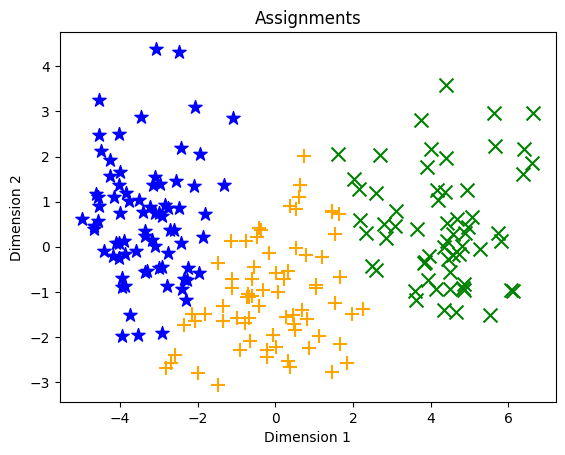

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline

pca = PCA(n_components=2).fit(features)
features_2d = pca.transform(features)

def plot_clusters(samples, clusters):
    col_dic = {0:'blue',1:'green',2:'orange'}
    mrk_dic = {0:'*',1:'x',2:'+'}
    colors = [col_dic[x] for x in clusters]
    markers = [mrk_dic[x] for x in clusters]
    for sample in range(len(clusters)):
        plt.scatter(samples[sample][0], samples[sample][1], color = colors[sample], marker=markers[sample], s=100)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.title('Assignments')
    plt.show()

plot_clusters(features_2d, km_clusters)